In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
bestfit = Table(ascii.read('cigale/out/results.txt'))
input = Table(ascii.read('cigale/out/observations.txt'))

# peas = ascii.read('photometry_results.csv')

# test = ascii.read('allsources.csv')
# tab = test[test['object_id']!= 'STACK']

# #### STATISTICAL FITTING CORRECTION
# ratio = tab['oiii5007_flux']/tab['oiii4959_flux']
# mask = np.isfinite(ratio)
# median = np.median(ratio[mask])
# tab['oiii4959_flux'] = tab['oiii4959_flux']*(median/3)

# SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
# EW_mask = (tab['oiii5007_ew']>100)|(tab['hbeta_ew']>50)
# selection0 = tab[SNR_mask&EW_mask].copy()
# common_ids_mask = np.isin(tab['object_id'], peas['object_id'])
# selection = tab[common_ids_mask]

master = Table(ascii.read('MASTER.csv'))

In [3]:
snrmask = master['oiii5007_ew_err']/master['oiii5007_ew']>0.3
master[snrmask] = np.nan

peasfinal=master


In [4]:
mstel = np.log10(bestfit['bayes.stellar.m_star'])
mstel_e = 0.432*bestfit['bayes.stellar.m_star_err']/bestfit['bayes.stellar.m_star']
objid = bestfit['id']

sedprops = hstack([mstel,mstel_e,objid])
sedprops.rename_column('bayes.stellar.m_star', 'logmstellar')
sedprops.rename_column('bayes.stellar.m_star_err', 'logmstellar_err')
sedprops.rename_column('id', 'object_id')

sedfit = join(master,sedprops)
peas_final=sedfit
# sedfit.remove_column('ra')
# sedfit.remove_column('dec')

# peas_final = join(master, sedfit, keys='object_id')

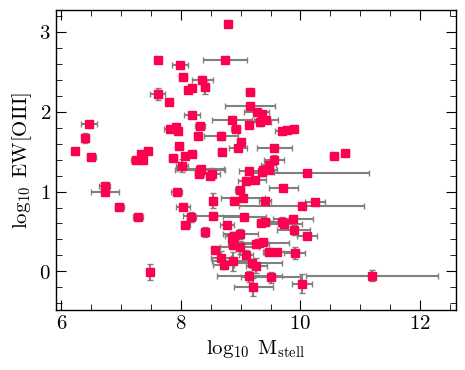

In [5]:
fig, ax = pf.create_plot()
ax.errorbar(peas_final['logmstellar'],np.log10(peas_final['oiii5007_ew']), 
            yerr=0.432*peas_final['oiii5007_ew_err']/peas_final['oiii5007_ew'], xerr=peas_final['logmstellar_err'],
            fmt='s', ecolor='gray', capsize=2, color='#ff004f')

ax.set_ylabel(r'$\log_{10}\;$EW[OIII]')
ax.set_xlabel(r'$\log_{10}\;\mathrm{M}_{\mathrm{stell}}$')


pf.fix_plot([ax])
fig.savefig(f'figs/masscdiff.png', dpi=600, bbox_inches='tight')

In [6]:
redshifts = peas_final['z']
lum_dist_cm = cosmo.luminosity_distance(redshifts).to(u.cm).value

oiii_flux_cgs = peas_final['oiii5007_flux'] * 1e-20
oiii_lum = oiii_flux_cgs * 4 * np.pi * lum_dist_cm**2

spitzer_flux_3_6_cgs = peas_final['flux_Spitzer_I1_3.6'] * 1e-6 * 1e-23
spitzer_flux_4_5_cgs = peas_final['flux_Spitzer_I2_4.5'] * 1e-6 * 1e-23

l_nu_3_6 = spitzer_flux_3_6_cgs * 4 * np.pi * lum_dist_cm**2
l_nu_4_5 = spitzer_flux_4_5_cgs * 4 * np.pi * lum_dist_cm**2

c_cm_s = 2.998e10  # Speed of light in cm/s
nu_3_6 = c_cm_s / (3.6 * 1e-4)  # 3.6 microns in cm
nu_4_5 = c_cm_s / (4.5 * 1e-4)  # 4.5 microns in cm

spitzer_lum_3_6 = nu_3_6 * l_nu_3_6
spitzer_lum_4_5 = nu_4_5 * l_nu_4_5

cont_est = peas_final['flux_HST_F435W']+peas_final['flux_HST_F606W']+peas_final['flux_HST_F814W']
spit_est = peas_final['flux_Spitzer_I1_3.6']+peas_final['flux_Spitzer_I2_4.5']

def get_log10err(tab, key):
    return 0.434*tab[key+'_err']/tab[key]

def pnm(flux, a=0.01, b=0.2):
    return np.sqrt(a * np.abs(1/flux)*50 + b**2)

def get_log10err2(val, err):
    """Calculates the error in log10 space."""
    return np.abs(0.434 * err / val)

oiii_lum_err = get_log10err2(peas_final['oiii5007_flux'], peas_final['oiii5007_flux_err'])

spitzer_flux_err_3_6 = pnm(peas_final['flux_Spitzer_I1_3.6'])
spitzer_flux_err_4_5 = np.abs(pnm(peas_final['flux_Spitzer_I2_4.5']))

spitzer_lum_3_6_err = get_log10err2(peas_final['flux_Spitzer_I1_3.6'], spitzer_flux_err_3_6)
spitzer_lum_4_5_err = get_log10err2(peas_final['flux_Spitzer_I2_4.5'], spitzer_flux_err_4_5)

logspitzer_flux_err_4_5 = get_log10err2(peas_final['flux_Spitzer_I2_4.5'],spitzer_flux_err_4_5)
logspitzer_flux_err_3_6 = get_log10err2(peas_final['flux_Spitzer_I1_3.6'],spitzer_flux_err_3_6)

colordiff = -2.5*np.log10(spitzer_flux_3_6_cgs/spitzer_flux_4_5_cgs)
frac = (spitzer_flux_3_6_cgs/spitzer_flux_4_5_cgs)
fracerr = frac*np.sqrt(
    (spitzer_flux_err_3_6/peas_final['flux_Spitzer_I1_3.6'])**2+
    (spitzer_flux_err_4_5/peas_final['flux_Spitzer_I2_4.5'])**2)
colordifferr = 0.482*fracerr/frac


def get_R23(sel):
    R23 = ((sel['oiii5007_flux']+sel['oiii4959_flux']+sel['oii3726_flux']+sel['oii3729_flux'])/sel['hbeta_flux']).data
    num_r23 = np.array((sel['oiii5007_flux'],sel['oiii4959_flux'],sel['oii3726_flux'],sel['oii3729_flux']))
    num_r23_err = np.array((sel['oiii5007_flux_err'],sel['oiii4959_flux_err'],sel['oii3726_flux_err'],sel['oii3729_flux_err']))
    R23_err = (np.sqrt((np.sqrt(np.sum(num_r23_err**2,axis=0))/np.sum(num_r23, axis=0))**2 + (sel['hbeta_flux_err'].data/sel['hbeta_flux'].data)**2)*R23)
    return R23, R23_err

R23, R23_err = get_R23(peas_final)

def get_O32(sel):
    num_o32 = np.array(sel['oiii5007_flux'])
    num_o32_err = np.array(sel['oiii5007_flux_err'])
    denom_o32 = np.array([sel['oii3729_flux'],sel['oii3726_flux']])
    denom_o32_err = np.array([sel['oii3729_flux_err'],sel['oii3726_flux_err']])
    O32 = num_o32/np.sum(denom_o32, axis=0)
    O32_err = np.sqrt((num_o32_err/num_o32)**2+(np.sqrt(np.sum(denom_o32_err**2, axis=0))/np.sum(denom_o32, axis=0))**2)*O32
    return O32, O32_err

O32, O32_err = get_O32(peas_final)

SNRmask = (O32/O32_err>5)&(R23/R23_err>5)

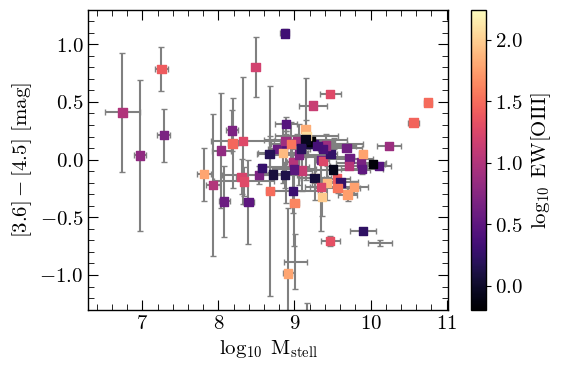

In [7]:
fig, ax = pf.create_plot((4.5,3))
# ax.errorbar(peas_final['logmstellar'],colordiff, 
#             yerr=colordifferr, xerr=peas_final['logmstellar_err'],
#             fmt='s', ecolor='gray', capsize=2, color='#ff004f')

mask = colordifferr<1

ax.errorbar(peas_final['logmstellar'][mask],colordiff[mask], 
            yerr=colordifferr[mask], xerr=peas_final['logmstellar_err'][mask],
            fmt='s', ecolor='gray', capsize=2, color='None')

sc = ax.scatter(peas_final['logmstellar'][mask],colordiff[mask], c=np.log10(peas_final['oiii5007_ew'])[mask],
                 zorder=10, cmap='magma', marker='s')

plt.colorbar(sc,label=r'$\log_{10}\;$EW[OIII]')

ax.set_ylabel(r'$[3.6]-[4.5]$ [mag]')
ax.set_xlabel(r'$\log_{10}\;\mathrm{M}_{\mathrm{stell}}$')

ax.set_ylim(-1.3,1.3)
pf.fix_plot([ax])
fig.savefig(f'figs/masscdiff.png', dpi=600, bbox_inches='tight')

In [8]:
peas_final['Z_dir_gen'] = np.ones_like(peas_final['z'])*1.031492
peas_final['Z_dir_gen_err'] = np.ones_like(peas_final['z'])*1.031492
peas_final['direct'] = np.ones_like(peas_final['z'])

peas_final_mask = (peas_final['hdelta_flux']>0)&(peas_final['oii3726_flux']>0)&(peas_final['oii3729_flux']>0)&(peas_final['hgamma_flux']>0)&(peas_final['hbeta_flux']>0)&(peas_final['oiii5007_flux']>0)&(peas_final['oiii4959_flux']>0)
peas_final_new = peas_final[peas_final_mask]

for p in peas_final_new:
    input_dict = {}
    input_dict['redshift'] =  p['z']
    input_dict['OII']      = [p['oii3726_flux']+p['oii3729_flux'],np.sqrt(np.sum(np.array([p['oii3726_flux_err'],p['oii3729_flux_err']])**2))]
    input_dict['Hdelta']   = [p['hdelta_flux'], p['hdelta_flux_err']]
    input_dict['Hgamma']   = [p['hgamma_flux'], p['hgamma_flux_err']]
    input_dict['Hbeta']    = [p['hbeta_flux'], p['hbeta_flux_err']]
    input_dict['O4959']    = [p['oiii4959_flux'],p['oiii4959_flux_err']]
    input_dict['O5007']    = [p['oiii5007_flux'],p['oiii5007_flux_err']]
    input_dict['Hbeta_EW'] = [p['hbeta_ew'], p['hbeta_ew_err']]

    direct = 0
    # if p['oiii4363_flux']>0:
    #     input_dict['O4363'] = [p['oiii4363_flux'],p['oiii4363_flux_err']]
    #     direct = 1

    try:
        galaxy = genesis_metallicity(input_dict)
        p['Z_dir_gen'] = galaxy.metallicity.n
        p['Z_dir_gen_err'] = galaxy.metallicity.s
        p['direct'] = direct
    except:
        print('FAILED')
        p['Z_dir_gen'] = np.nan
        p['Z_dir_gen_err'] = np.nan
        p['direct'] = np.nan  

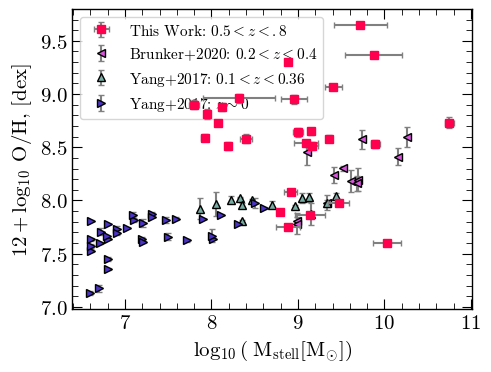

In [9]:
fig, ax = pf.create_plot()

mask = peas_final_new['z']>0
sc = ax.errorbar(peas_final_new['logmstellar'][mask],peas_final_new['Z_dir_gen'][mask], 
                xerr = peas_final_new['logmstellar_err'][mask], yerr=peas_final_new['Z_dir_gen_err'][mask],
                capsize=2, ecolor='gray', fmt='s', color='#ff004f',  label=r'This Work: $0.5<z<.8$', zorder=50)

brunkerPeas = ascii.read('brunkerPeas.csv')
# ax.scatter(brunkerPeas['x'], brunkerPeas['y'], color="#d856db", marker='<', label=r'Brunker+2020: $0.2<z<0.4$', edgecolors='k')

ax.errorbar(brunkerPeas['x'], brunkerPeas['y'], mfc="#d856db", fmt='<', 
            label=r'Brunker+2020: $0.2<z<0.4$', mec='k', yerr=np.abs(np.random.normal(0,0.08,size=len(brunkerPeas['y']))),
            ecolor='grey', capsize=2)


yangBlues = ascii.read('yangPs.csv')
# ax.scatter(yangBlues['x'], yangBlues['y'], color="#77aca2", marker='^', label=r'Yang+2017: $0.1<z<0.36$', edgecolors='k')

ax.errorbar(yangBlues['x'], yangBlues['y'], mfc="#77aca2", fmt='^', 
            label=r'Yang+2017: $0.1<z<0.36$', mec='k', yerr=np.abs(np.random.normal(0,0.08,size=len(yangBlues['y']))),
            ecolor='grey', capsize=2)

yangPeas = ascii.read('yangBlues.csv')
# ax.scatter(yangPeas['x'], yangPeas['y'], color="#4c33c8", marker='>', label=r'Yang+2017: $z\sim0$', edgecolors='k')

ax.errorbar(yangPeas['x'], yangPeas['y'], mfc="#4c33c8", fmt='>', 
            label=r'Yang+2017: $z\sim0$', mec='k', yerr=np.abs(np.random.normal(0,0.02,size=len(yangPeas['y']))),
            ecolor='grey', capsize=2)

# fig.legend(bbox_to_anchor=(1, 1.5))
ax.legend(fontsize=11)

ax.set_ylabel(r'$12+\log_{10}\;$O/H, [dex]')
ax.set_xlabel(r'$\log_{10}(\;\mathrm{M}_{\mathrm{stell}} [\mathrm{M}_{\odot}])$')

pf.fix_plot([ax])

fig.savefig(f'figs/massmet.png', dpi=600, bbox_inches='tight')

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_24370/3220100474.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


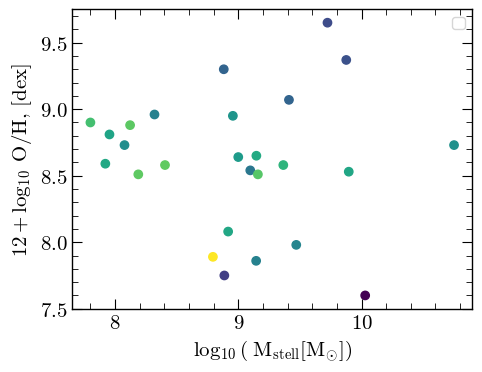

In [10]:
fig, ax = pf.create_plot()

# mask = peas_final_new['z']>0
# sc = ax.errorbar(peas_final_new['logmstellar'][mask],peas_final_new['Z_dir_gen'][mask], 
#                 xerr = peas_final_new['logmstellar_err'][mask], yerr=peas_final_new['Z_dir_gen_err'][mask],
#                 capsize=2, ecolor='gray', fmt='s', color='#ff004f',  label=r'This Work: $0.5<z<.8$', zorder=50)

ax.scatter(peas_final_new['logmstellar'][mask],peas_final_new['Z_dir_gen'][mask], c=np.log10(peas_final_new['oiii5007_ew'][mask]))
# fig.legend(bbox_to_anchor=(1, 1.5))
ax.legend(fontsize=11)

ax.set_ylabel(r'$12+\log_{10}\;$O/H, [dex]')
ax.set_xlabel(r'$\log_{10}(\;\mathrm{M}_{\mathrm{stell}} [\mathrm{M}_{\odot}])$')

pf.fix_plot([ax])

fig.savefig(f'figs/massmet.png', dpi=600, bbox_inches='tight')

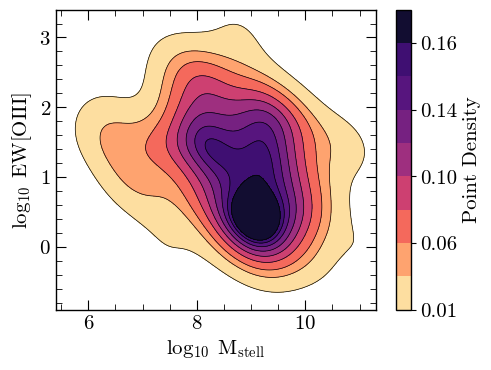

In [11]:
import seaborn as sns
fig, ax = pf.create_plot()

peas_final_df = peas_final.to_pandas()
peas_final_df['log_oiii5007_ew'] = np.log10(peas_final_df['oiii5007_ew'])

# 2. Create the 2D Kernel Density plot with Seaborn

# First call: Draw the filled colormap and create the colorbar.
sns.kdeplot(
    data=peas_final_df,
    x='logmstellar', 
    y='log_oiii5007_ew',
    fill=True,
    cmap='magma_r',
    ax=ax,
    cbar=True,
    cbar_kws={'label': 'Point Density', 'format': '%.2f'},
    thresh=0.05
)

# --- Manual Colorbar Modification ---
# The contour plot artist is the first item in the axes' collections
mappable = ax.collections[0] 
# This artist has a direct reference to the colorbar object
cbar = mappable.colorbar
# Get the current tick locations
current_ticks = cbar.get_ticks()
# Set the new ticks to be every other one from the original list
cbar.set_ticks(current_ticks[::2])
# --- End Modification ---


# Second call: Overlay the contour lines in a different color.
sns.kdeplot(
    data=peas_final_df,
    x='logmstellar', 
    y='log_oiii5007_ew',
    fill=False,
    color='k',
    linewidths=0.5,
    ax=ax,
    thresh=0.05
)


# 3. Set labels and fix plot as before
ax.set_ylabel(r'$\log_{10}\;$EW[OIII]')
ax.set_xlabel(r'$\log_{10}\;\mathrm{M}_{\mathrm{stell}}$')

ax.set_xlim([5.4,11.3])
ax.set_ylim([-0.9,3.4])


pf.fix_plot([ax])
fig.savefig(f'figs/mass_ew_density_seaborn_no_zero.png', dpi=600, bbox_inches='tight')


plt.show() # Optional: to display the plot interactively

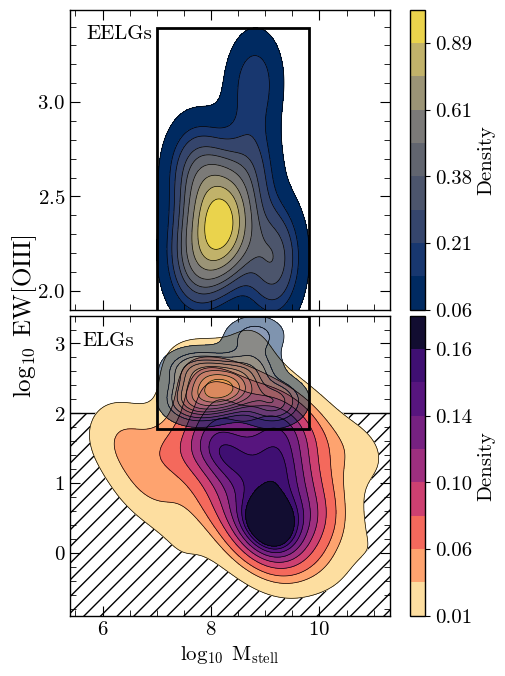

In [12]:
from old_plot_help import create_mass_ew_density_plot
create_mass_ew_density_plot(peas_final, 'test')

In [13]:
massmet_new_method = Table([peas_final_new['logmstellar'][mask].data,
                              peas_final_new['Z_dir_gen'][mask].data,
                              peas_final_new['logmstellar_err'][mask].data,
                              peas_final_new['Z_dir_gen_err'][mask].data, peas_final_new['z']], names=('logmstellar','zdir','merror','zerror','z'))
massmet_new_method.write('massmet_new.csv', overwrite=True)

In [14]:
peas_final.write('ELGS_withmasses.csv')